In [127]:
import os
print(os.chdir(r"C:\Users\user\Desktop\Titanic-Survival-Prediction\datasetdata"))

None


In [128]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df = pd.read_csv("Titanic-Dataset.csv",engine="python")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [129]:
print("Rows & Columns:", df.shape)
df.info()
df.describe()

Rows & Columns: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [130]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [131]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [132]:
# Remove unnecessary columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
existing_cols = [col for col in cols_to_drop if col in df.columns]

df.drop(columns=existing_cols, inplace=True)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


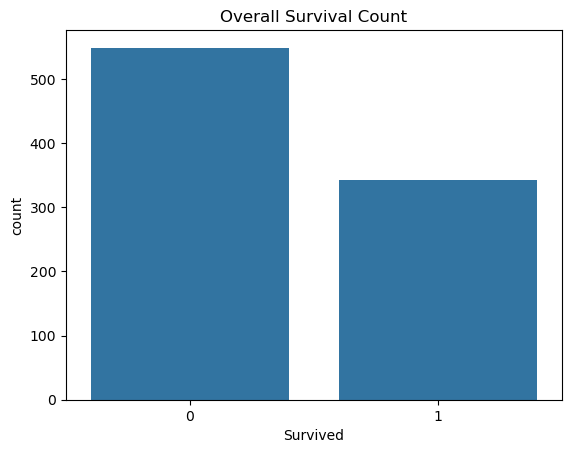

In [133]:
sns.countplot(x='Survived', data=df)
plt.title("Overall Survival Count")
plt.show()


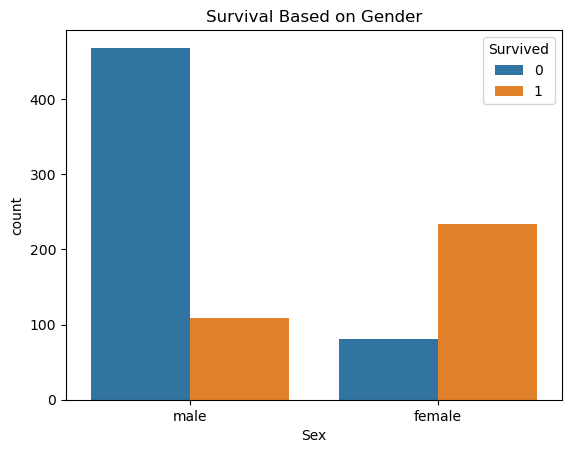

In [134]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Based on Gender")
plt.show()


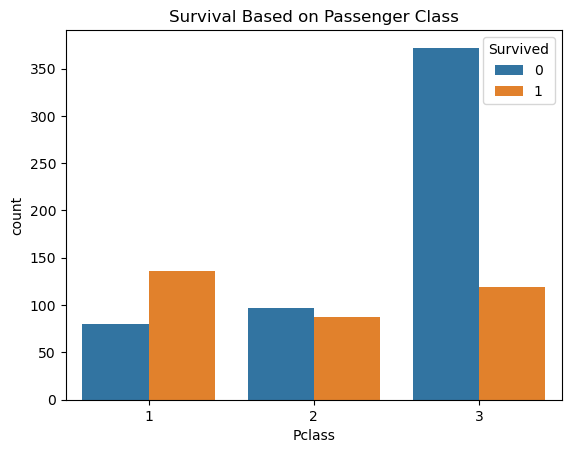

In [135]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival Based on Passenger Class")
plt.show()


In [136]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

df[['Sex', 'Embarked']].head()


,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


In [137]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (891, 7)
Target shape: (891,)


In [138]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 0.82737724,  0.73769513, -0.56573646,  0.43279337, -0.47367361,
        -0.50244517,  0.58595414],
       [-1.56610693, -1.35557354,  0.66386103,  0.43279337, -0.47367361,
         0.78684529, -1.9423032 ],
       [ 0.82737724, -1.35557354, -0.25833709, -0.4745452 , -0.47367361,
        -0.48885426,  0.58595414],
       [-1.56610693, -1.35557354,  0.4333115 ,  0.43279337, -0.47367361,
         0.42073024,  0.58595414],
       [ 0.82737724,  0.73769513,  0.4333115 , -0.4745452 , -0.47367361,
        -0.48633742,  0.58595414]])

In [139]:
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (712, 7)
Testing data shape: (179, 7)


In [140]:
model = LogisticRegression( max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)
print("Model trained successfully")


Model trained successfully


In [141]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [142]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8156424581005587


In [143]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.80      0.84       105
           1       0.75      0.84      0.79        74

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



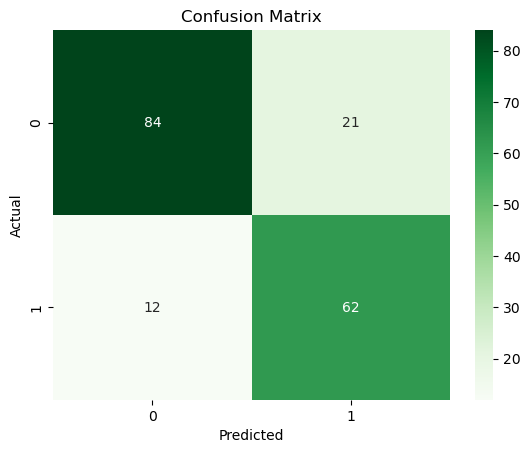

In [144]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [145]:
print("Model exists:", 'model' in globals())
print("Scaler exists:", 'scaler' in globals())
print("Features count:", X.shape[1])

Model exists: True
Scaler exists: True
Features count: 7


In [146]:
# Sample passenger data
sample_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 1,
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 2 }])

sample_scaled = scaler.transform(sample_passenger)

prediction = model.predict(sample_scaled)
print("Survived" if prediction[0] == 1 else "Did Not Survive")


Did Not Survive
